# Notebook 4 — Alert Rules & Dissemination — Completed
Source: DigiHaz Module 7 Topic 4 `04_alerting_exercise.ipynb`. Telegram and ntfy are kept in mock mode because no credentials/outbound network are available.


In [1]:
from datetime import datetime, timezone, timedelta
import numpy as np, pandas as pd, matplotlib.pyplot as plt
RULES=[
{'name':'RED','condition':lambda r:r['tilt_deg']>10 and r['soil_pct']>90,'duration_s':120,'severity':'critical'},
{'name':'YELLOW','condition':lambda r:r['tilt_deg']>5 and r['soil_pct']>80 and not(r['tilt_deg']>10 and r['soil_pct']>90),'duration_s':120,'severity':'warning'},
{'name':'STORM','condition':lambda r:r.get('pressure_trend_hpa_hr',0)<-2,'duration_s':300,'severity':'warning'}]
print([(r['name'],r['duration_s']) for r in RULES])


[('RED', 120), ('YELLOW', 120), ('STORM', 300)]


In [2]:
class AlertStateMachine:
    def __init__(self): self.state={}
    def evaluate(self,rule,reading,now=None):
        now=now or datetime.now(timezone.utc); site=reading.get('site','unknown'); key=(rule['name'],site)
        cur=self.state.get(key,{'state':'OK','since':now,'last_seen':now}); cond=rule['condition'](reading); event=None
        if cur['state']=='OK':
            if cond: cur={'state':'PENDING','since':now,'last_seen':now}
        elif cur['state']=='PENDING':
            if not cond: cur={'state':'OK','since':now,'last_seen':now}
            elif (now-cur['since']).total_seconds()>=rule['duration_s']:
                event={'type':'FIRING_START','rule':rule,'site':site,'reading':reading,'time':now}; cur={'state':'FIRING','since':now,'last_seen':now}
        elif cur['state']=='FIRING':
            if not cond: event={'type':'RESOLVED','rule':rule,'site':site,'reading':reading,'time':now}; cur={'state':'OK','since':now,'last_seen':now}
            else: cur['last_seen']=now
        self.state[key]=cur; return event
base=datetime(2026,10,1,0,0,tzinfo=timezone.utc); sm=AlertStateMachine(); seq=[(2,40),(11,92),(12,93),(12.5,93),(13,94),(12,93),(4,50),(3,40)]
for i,(tilt,soil) in enumerate(seq):
    now=base+timedelta(seconds=i*30); e=sm.evaluate(RULES[0],{'site':'site_test','tilt_deg':tilt,'soil_pct':soil},now)
    print(now.strftime('%H:%M:%S'),sm.state[('RED','site_test')]['state'],None if not e else e['type'])


00:00:00 OK None
00:00:30 PENDING None
00:01:00 PENDING None
00:01:30 PENDING None
00:02:00 PENDING None
00:02:30 FIRING FIRING_START
00:03:00 OK RESOLVED
00:03:30 OK None


**State-machine observation:** because the RED condition first becomes true at +30 s, a 120-second `For:` duration is satisfied at +150 s, not +120 s.


## Telegram / browser push in mock mode


In [3]:
def send_telegram(text): print('[TELEGRAM mock]',text); return False
def send_ntfy(title,message): print('[NTFY mock]',title,'—',message); return False
send_telegram('DigiHaz test'); send_ntfy('DigiHaz test','offline execution')


[TELEGRAM mock] DigiHaz test
[NTFY mock] DigiHaz test — offline execution


False

## 24-hour synthetic storm scenario


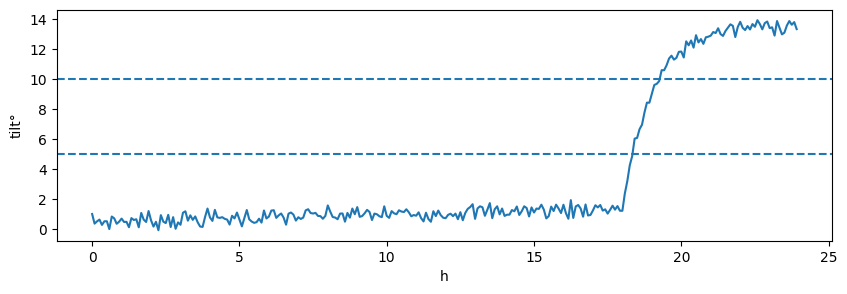

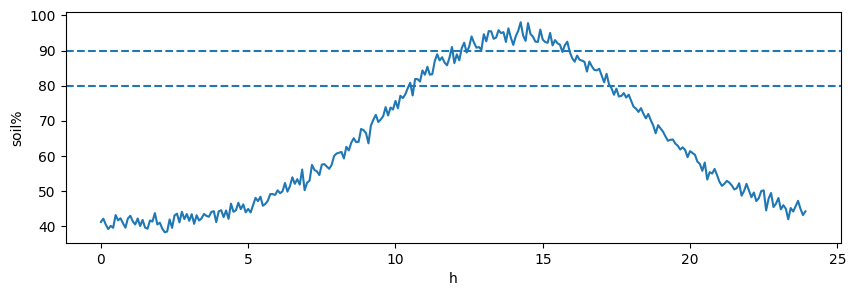

Max tilt 13.92°; max soil 98.05%; min pressure trend -3.20 hPa/hr


In [4]:
np.random.seed(7); hours=24; n=hours*12; start=base-timedelta(hours=hours); t=np.arange(n)*5/60
times=[start+timedelta(minutes=5*i) for i in range(n)]
tilt=.5+.05*t+np.where(t>18,12*(1-np.exp(-(t-18))),0)+np.random.normal(0,.3,n)
pressure=1013-12*np.exp(-((t-10)/5)**2)+np.random.normal(0,.4,n)
soil=np.clip(40+55*np.exp(-((t-14)/6)**2)+np.random.normal(0,1.5,n),0,100)
trend=pd.Series(pressure).diff(12).fillna(0).values
readings=[{'site':'site_delta','tilt_deg':tilt[i],'press_hpa':pressure[i],'soil_pct':soil[i],'pressure_trend_hpa_hr':trend[i]} for i in range(n)]
plt.figure(figsize=(10,3)); plt.plot(t,tilt); plt.axhline(5,ls='--'); plt.axhline(10,ls='--'); plt.xlabel('h'); plt.ylabel('tilt°'); plt.show()
plt.figure(figsize=(10,3)); plt.plot(t,soil); plt.axhline(80,ls='--'); plt.axhline(90,ls='--'); plt.xlabel('h'); plt.ylabel('soil%'); plt.show()
print(f'Max tilt {tilt.max():.2f}°; max soil {soil.max():.2f}%; min pressure trend {trend.min():.2f} hPa/hr')


In [5]:
sm=AlertStateMachine(); events=[]
for i,reading in enumerate(readings):
    now=times[i]
    for rule in RULES:
        e=sm.evaluate(rule,reading,now)
        if e: events.append(e)
print('state transitions',len(events),'firing',sum(e['type']=='FIRING_START' for e in events),'resolved',sum(e['type']=='RESOLVED' for e in events))
print('rules represented:',sorted(set(e['rule']['name'] for e in events)))


state transitions 12 firing 6 resolved 6
rules represented: ['STORM']


## Extension B — Planned-maintenance silencing


In [6]:
class SilencingAlertStateMachine(AlertStateMachine):
    def __init__(self,silences=None): super().__init__(); self.silences=silences or []
    def is_silenced(self,rule_name,site,now):
        return any(rn==rule_name and s==site and a<=now<=b for rn,s,a,b in self.silences)
    def evaluate(self,rule,reading,now=None):
        now=now or datetime.now(timezone.utc); site=reading.get('site','unknown'); key=(rule['name'],site)
        if self.is_silenced(rule['name'],site,now):
            self.state[key]={'state':'OK','since':now,'last_seen':now}; return None
        return super().evaluate(rule,reading,now)
t0=datetime(2026,10,1,10,0,tzinfo=timezone.utc); t1=t0+timedelta(minutes=5)
sm=SilencingAlertStateMachine([('RED','site_test',t0,t1)])
test=[(t0+timedelta(minutes=1),12,95),(t0+timedelta(minutes=4),13,96),(t1+timedelta(seconds=30),12,95),(t1+timedelta(seconds=90),12,95),(t1+timedelta(seconds=150),12,95),(t1+timedelta(seconds=180),4,50)]
for now,tilt_v,soil_v in test:
    e=sm.evaluate(RULES[0],{'site':'site_test','tilt_deg':tilt_v,'soil_pct':soil_v},now)
    print(now.strftime('%H:%M:%S'),'silenced=',sm.is_silenced('RED','site_test',now),'state=',sm.state[('RED','site_test')]['state'],'event=',None if not e else e['type'])


10:01:00 silenced= True state= OK event= None
10:04:00 silenced= True state= OK event= None
10:05:30 silenced= False state= PENDING event= None
10:06:30 silenced= False state= PENDING event= None
10:07:30 silenced= False state= FIRING event= FIRING_START
10:08:00 silenced= False state= OK event= RESOLVED


## Extension reflection
In Python, silencing is easy to prototype and unit-test because the state machine is explicit. For field operations, I would use Grafana’s native silences/mute timings rather than re-implementing the behavior inside a query: Grafana persists state, exposes schedules to operators, centralizes routing, and keeps an audit trail. For research I would prototype compound/adaptive logic in Python, validate it on labelled data, then reproduce the validated rule in Grafana for 24/7 operation. Maintenance silences should suppress operational notifications without making suspect sensor data scientifically valid.
